# Part 1: world2 model characterization

This notebook runs the baseline together with eight test scenarios.

The simulations are written out scenario by scenario, so each parameter change is tied directly to one JSON switch file:

- lower and higher capital investment rate
- lower and higher birth rate
- lower and higher death rate
- lower and higher pollution production rate


In [3]:
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [4]:
start_dir = Path.cwd().resolve()
repo_root = None

for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "pyworld2-main" / "pyworld2").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise FileNotFoundError("Could not locate the CIVIL-534 repository root.")

pyworld2_root = repo_root / "pyworld2-main"
test_dir = repo_root / "milestone_part1"
default_switch_path = pyworld2_root / "pyworld2" / "functions_switch_default.json"

if str(pyworld2_root) not in sys.path:
    sys.path.insert(0, str(pyworld2_root))

from pyworld2 import World2

In [5]:
standard_model = World2()
standard_model.set_state_variables()
standard_model.set_initial_state()
standard_model.set_table_functions()
standard_model.set_switch_functions(str(default_switch_path))
standard_model.run()

lower_capital_switch_path = test_dir / "capital_investment_rate.json"
lower_capital_model = World2()
lower_capital_model.set_state_variables()
lower_capital_model.set_initial_state()
lower_capital_model.set_table_functions()
lower_capital_model.set_switch_functions(str(lower_capital_switch_path))
lower_capital_model.run()

higher_capital_switch_path = test_dir / "capital_investment_rate_higher.json"
higher_capital_model = World2()
higher_capital_model.set_state_variables()
higher_capital_model.set_initial_state()
higher_capital_model.set_table_functions()
higher_capital_model.set_switch_functions(str(higher_capital_switch_path))
higher_capital_model.run()

lower_birth_switch_path = test_dir / "birth_rate.json"
lower_birth_model = World2()
lower_birth_model.set_state_variables()
lower_birth_model.set_initial_state()
lower_birth_model.set_table_functions()
lower_birth_model.set_switch_functions(str(lower_birth_switch_path))
lower_birth_model.run()

higher_birth_switch_path = test_dir / "birth_rate_higher.json"
higher_birth_model = World2()
higher_birth_model.set_state_variables()
higher_birth_model.set_initial_state()
higher_birth_model.set_table_functions()
higher_birth_model.set_switch_functions(str(higher_birth_switch_path))
higher_birth_model.run()

lower_death_switch_path = test_dir / "death_rate.json"
lower_death_model = World2()
lower_death_model.set_state_variables()
lower_death_model.set_initial_state()
lower_death_model.set_table_functions()
lower_death_model.set_switch_functions(str(lower_death_switch_path))
lower_death_model.run()

higher_death_switch_path = test_dir / "death_rate_higher.json"
higher_death_model = World2()
higher_death_model.set_state_variables()
higher_death_model.set_initial_state()
higher_death_model.set_table_functions()
higher_death_model.set_switch_functions(str(higher_death_switch_path))
higher_death_model.run()

lower_pollution_switch_path = test_dir / "pollution_production_rate.json"
lower_pollution_model = World2()
lower_pollution_model.set_state_variables()
lower_pollution_model.set_initial_state()
lower_pollution_model.set_table_functions()
lower_pollution_model.set_switch_functions(str(lower_pollution_switch_path))
lower_pollution_model.run()

higher_pollution_switch_path = test_dir / "pollution_production_rate_higher.json"
higher_pollution_model = World2()
higher_pollution_model.set_state_variables()
higher_pollution_model.set_initial_state()
higher_pollution_model.set_table_functions()
higher_pollution_model.set_switch_functions(str(higher_pollution_switch_path))
higher_pollution_model.run()


In [6]:
scenario_models = [
    ("Standard run", standard_model),
    ("Lower capital investment", lower_capital_model),
    ("Higher capital investment", higher_capital_model),
    ("Lower birth rate", lower_birth_model),
    ("Higher birth rate", higher_birth_model),
    ("Lower death rate", lower_death_model),
    ("Higher death rate", higher_death_model),
    ("Lower pollution production", lower_pollution_model),
    ("Higher pollution production", higher_pollution_model),
]

summary_rows = []

for scenario_name, model in scenario_models:
    quality_of_life = pd.Series(model.ql).dropna()
    summary_rows.append(
        {
            "Scenario": scenario_name,
            "Peak population (billions)": model.p.max() / 1e9,
            "Peak population year": float(model.time[model.p.argmax()]),
            "Resources remaining in 2100 (%)": model.nr[-1] / model.nr[0] * 100,
            "Peak pollution (multiple of initial)": model.pol.max() / model.pol[0],
            "Peak pollution year": float(model.time[model.pol.argmax()]),
            "Final quality of life": quality_of_life.iloc[-1],
            "Minimum quality of life": quality_of_life.min(),
        }
    )

summary_df = pd.DataFrame(summary_rows).round(
    {
        "Peak population (billions)": 3,
        "Peak population year": 1,
        "Resources remaining in 2100 (%)": 1,
        "Peak pollution (multiple of initial)": 2,
        "Peak pollution year": 1,
        "Final quality of life": 3,
        "Minimum quality of life": 3,
    }
)

summary_df


,Scenario,Peak population (billions),Peak population year,Resources remaining in 2100 (%),Peak pollution (multiple of initial),Peak pollution year,Final quality of life,Minimum quality of life
0,Standard run,5.296,2020.4,30.9,102.83,2050.6,0.549,0.549
1,Lower capital investment,4.715,2018.6,39.2,34.72,2041.4,0.579,0.579
2,Higher capital investment,5.461,2014.2,29.0,715.78,2042.6,0.685,0.254
3,Lower birth rate,4.660,2026.4,30.4,118.81,2051.0,0.678,0.616
4,Higher birth rate,5.633,2019.6,31.8,88.42,2050.0,0.464,0.464
5,Lower death rate,5.641,2021.6,31.8,87.78,2049.2,0.447,0.447
6,Higher death rate,4.921,2023.8,30.5,114.27,2051.4,0.649,0.616
7,Lower pollution production,5.508,2024.8,31.0,34.45,2046.2,0.515,0.515
8,Higher pollution production,4.910,2011.8,36.6,783.28,2048.6,1.036,0.210


In [7]:
timeseries_frames = []

for scenario_name, model in scenario_models:
    scenario_frame = pd.DataFrame(
        {
            "Scenario": scenario_name,
            "Year": model.time,
            "Population (billions)": model.p / 1e9,
            "Pollution (multiple of initial)": model.pol / model.pol[0],
            "Natural resources remaining (%)": model.nr / model.nr[0] * 100,
            "Quality of life": model.ql,
        }
    )
    timeseries_frames.append(scenario_frame)

timeseries_df = pd.concat(timeseries_frames, ignore_index=True)
timeseries_df.head()


,Scenario,Year,Population (billions),Pollution (multiple of initial),Natural resources remaining (%),Quality of life
0,Standard run,1900.0,1.650000,1.000000,100.000000,NaN
1,Standard run,1900.2,1.648231,1.134929,99.989841,0.616037
2,Standard run,1900.4,1.646567,1.230013,99.979592,0.620497
3,Standard run,1900.6,1.645011,1.298189,99.969252,0.624963
4,Standard run,1900.8,1.643564,1.348146,99.958820,0.629426


## Combined scenario visualization



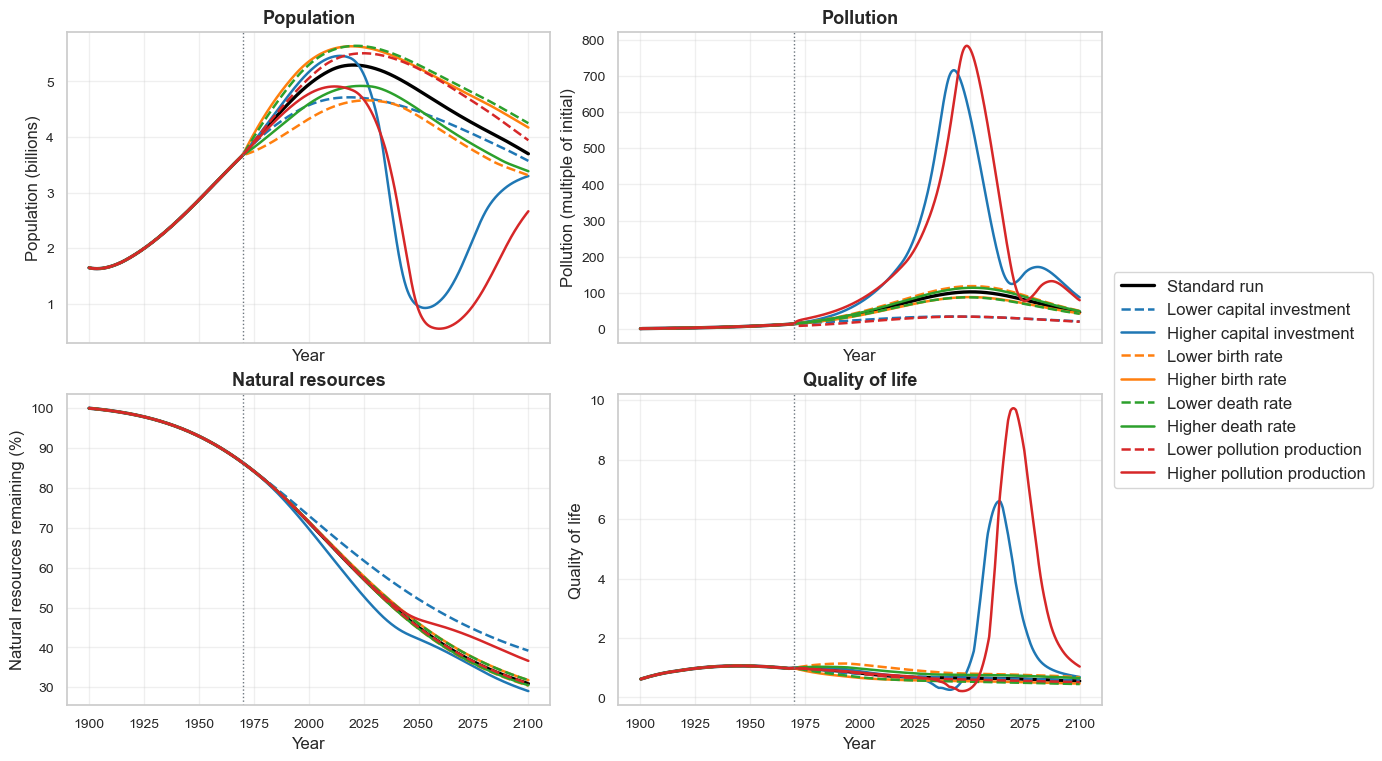

In [34]:
scenario_style = {
    "Standard run":                ("#000000", "-",  2.4),
    "Lower capital investment":    ("#1f77b4", "--", 1.8),
    "Higher capital investment":   ("#1f77b4", "-",  1.8),
    "Lower birth rate":            ("#ff7f0e", "--", 1.8),
    "Higher birth rate":           ("#ff7f0e", "-",  1.8),
    "Lower death rate":            ("#2ca02c", "--", 1.8),
    "Higher death rate":           ("#2ca02c", "-",  1.8),
    "Lower pollution production":  ("#d62728", "--", 1.8),
    "Higher pollution production": ("#d62728", "-",  1.8),
}

metric_specs = [
    ("Population (billions)", "Population"),
    ("Pollution (multiple of initial)", "Pollution"),
    ("Natural resources remaining (%)", "Natural resources"),
    ("Quality of life", "Quality of life"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True, constrained_layout=True)
axes = axes.flatten()

for index, (metric_column, title) in enumerate(metric_specs):
    ax = axes[index]
    for scenario_name, (color, linestyle, linewidth) in scenario_style.items():
        subset = timeseries_df[timeseries_df["Scenario"] == scenario_name]
        ax.plot(subset["Year"], subset[metric_column],
                color=color, linestyle=linestyle, linewidth=linewidth,
                label=scenario_name)
    ax.axvline(1970, linestyle=":", linewidth=1, color="#6c757d")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel(metric_column, fontsize=12)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="center left",
           bbox_to_anchor=(1.00, 0.5),
           fontsize=12,
           frameon=True)

plt.show()


In [ ]:
summary_heatmap = summary_df.set_index("Scenario")[[
    "Peak population (billions)",
    "Peak pollution (multiple of initial)",
    "Resources remaining in 2100 (%)",
    "Final quality of life",
]]
summary_heatmap.columns = [
    "Peak population",
    "Peak pollution",
    "Resources left in 2100",
    "Final quality of life",
]

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(
    summary_heatmap,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    annot_kws={"size": 12},
    ax=ax,
)
ax.set_title("Scenario summary heatmap", fontsize=14, fontweight="bold")
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Scenario", fontsize=12)
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


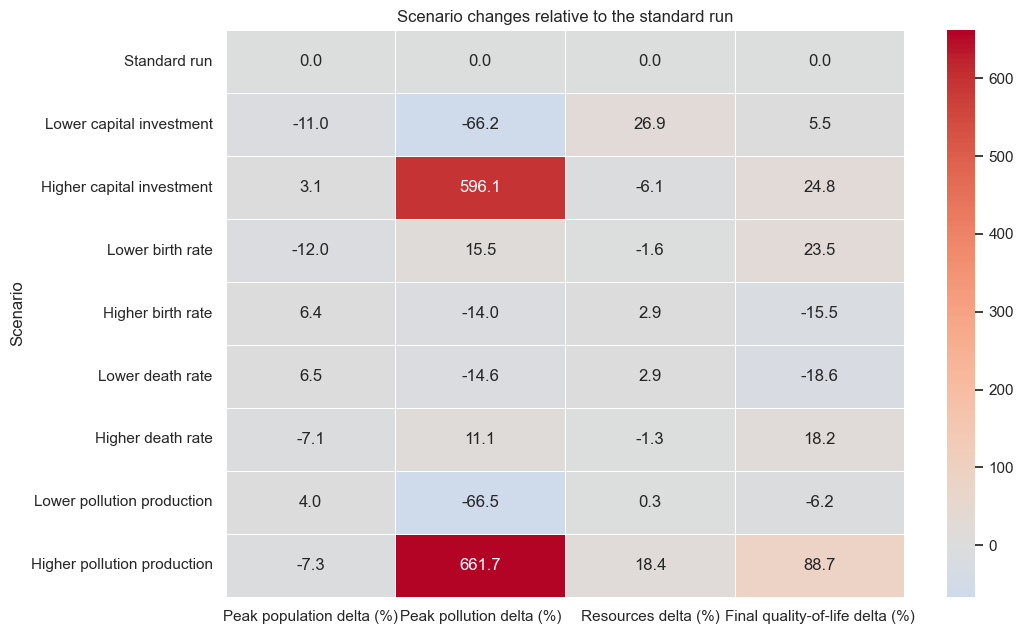

In [10]:
baseline_row = summary_df.loc[summary_df["Scenario"] == "Standard run"].iloc[0]
change_rows = []

for _, row in summary_df.iterrows():
    change_rows.append(
        {
            "Scenario": row["Scenario"],
            "Peak population delta (%)": (row["Peak population (billions)"] - baseline_row["Peak population (billions)"]) / baseline_row["Peak population (billions)"] * 100,
            "Peak pollution delta (%)": (row["Peak pollution (multiple of initial)"] - baseline_row["Peak pollution (multiple of initial)"]) / baseline_row["Peak pollution (multiple of initial)"] * 100,
            "Resources delta (%)": (row["Resources remaining in 2100 (%)"] - baseline_row["Resources remaining in 2100 (%)"]) / baseline_row["Resources remaining in 2100 (%)"] * 100,
            "Final quality-of-life delta (%)": (row["Final quality of life"] - baseline_row["Final quality of life"]) / baseline_row["Final quality of life"] * 100,
        }
    )

change_df = pd.DataFrame(change_rows).set_index("Scenario").round(1)

plt.figure(figsize=(11, 6.5))
sns.heatmap(change_df, annot=True, fmt=".1f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Scenario changes relative to the standard run")
plt.tight_layout()
plt.show()


## Leverage-point exploration

The directional tests above compare the required scenario runs one by one. To keep the parameter exploration coherent while making it more systematic, the notebook now extends the same World2 setup with a small leverage-point screen.

Each run changes only one post-1970 parameter by $\pm 20\%$ while keeping the rest of the model structure unchanged. The purpose is to compare relative sensitivity under the selected output metrics, not to claim a universal policy ranking.


In [31]:
import copy
import json
import numpy as np
import tempfile
from IPython.display import display

generated_leverage_dir = Path(tempfile.gettempdir()) / "world2_parameter_tests_generated_leverage_switches"
generated_leverage_dir.mkdir(parents=True, exist_ok=True)

def load_default_switches():
    with open(default_switch_path, "r", encoding="utf-8") as handle:
        return json.load(handle)

def write_generated_switch_file(name, updates, trigger_year=1970):
    data = copy.deepcopy(load_default_switches())

    for row in data:
        for key, value in updates.items():
            if key in row:
                row[key] = value
        if "trigger.value" in row:
            row["trigger.value"] = trigger_year

    path = generated_leverage_dir / f"{name}.json"
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")
    return path

def run_generated_world2(name, updates, trigger_year=1970):
    switch_path = write_generated_switch_file(name, updates, trigger_year=trigger_year)
    model = World2()
    model.set_state_variables()
    model.set_initial_state()
    model.set_table_functions()
    model.set_switch_functions(str(switch_path))
    model.run()
    return model


In [32]:
leverage_params = {
    "BRN (Birth rate)": 0.04,
    "DRN (Death rate)": 0.028,
    "CIGN (Capital investment rate)": 0.05,
    "CIDN (Capital depreciation)": 0.025,
    "NRUN (Resource use rate)": 1.0,
    "POLN (Pollution rate)": 1.0,
    "FC (Food coefficient)": 1.0,
}

leverage_base_model = run_generated_world2("leverage_base", {})
leverage_base_qol = pd.Series(leverage_base_model.ql).dropna().iloc[-1]
leverage_base_peak_population = leverage_base_model.p.max() / 1e9

leverage_rows = []

for parameter_label, baseline_value in leverage_params.items():
    parameter_key = parameter_label.split(" ")[0] + "1"

    for direction, factor in [("-20%", 0.8), ("+20%", 1.2)]:
        updated_value = baseline_value * factor
        model = run_generated_world2(
            name=f"leverage_{parameter_key}_{str(factor).replace('.', '_')}",
            updates={parameter_key: updated_value},
        )

        final_qol = pd.Series(model.ql).dropna().iloc[-1]
        peak_population = model.p.max() / 1e9

        leverage_rows.append(
            {
                "Parameter": parameter_label,
                "Direction": direction,
                "Updated value": updated_value,
                "Final quality of life": final_qol,
                "Final QoL change (%)": (final_qol - leverage_base_qol) / leverage_base_qol * 100,
                "Peak population (billions)": peak_population,
                "Peak population change (%)": (peak_population - leverage_base_peak_population) / leverage_base_peak_population * 100,
            }
        )

leverage_results_df = pd.DataFrame(leverage_rows)

leverage_sensitivity_df = (
    leverage_results_df.groupby("Parameter")
    .agg(
        avg_qol_sensitivity=("Final QoL change (%)", lambda values: values.abs().mean()),
        avg_population_sensitivity=("Peak population change (%)", lambda values: values.abs().mean()),
    )
    .reset_index()
    .sort_values("avg_qol_sensitivity", ascending=False)
)

display(
    leverage_results_df.round(
        {
            "Updated value": 3,
            "Final quality of life": 3,
            "Final QoL change (%)": 1,
            "Peak population (billions)": 3,
            "Peak population change (%)": 1,
        }
    )
)

display(
    leverage_sensitivity_df.rename(
        columns={
            "avg_qol_sensitivity": "Average |QoL change| (%)",
            "avg_population_sensitivity": "Average |peak population change| (%)",
        }
    ).round(1)
)


,Parameter,Direction,Updated value,Final quality of life,Final QoL change (%),Peak population (billions),Peak population change (%)
0,BRN (Birth rate),-20%,0.032,0.652,18.6,4.809,-9.2
1,BRN (Birth rate),+20%,0.048,0.479,-12.8,5.571,5.2
2,DRN (Death rate),-20%,0.022,0.454,-17.4,5.615,6.0
3,DRN (Death rate),+20%,0.034,0.644,17.1,4.947,-6.6
4,CIGN (Capital investment rate),-20%,0.040,0.579,5.4,4.715,-11.0
5,CIGN (Capital investment rate),+20%,0.060,0.685,24.6,5.461,3.1
6,CIDN (Capital depreciation),-20%,0.020,0.845,53.7,5.450,2.9
7,CIDN (Capital depreciation),+20%,0.030,0.563,2.5,4.961,-6.3
8,NRUN (Resource use rate),-20%,0.800,0.629,14.5,5.475,3.4
9,NRUN (Resource use rate),+20%,1.200,0.516,-6.1,5.115,-3.4


,Parameter,Average |QoL change| (%),Average |peak population change| (%)
6,POLN (Pollution rate),28.8,2.7
1,CIDN (Capital depreciation),28.1,4.6
3,DRN (Death rate),17.3,6.3
0,BRN (Birth rate),15.7,7.2
2,CIGN (Capital investment rate),15.0,7.0
4,FC (Food coefficient),14.2,11.5
5,NRUN (Resource use rate),10.3,3.4


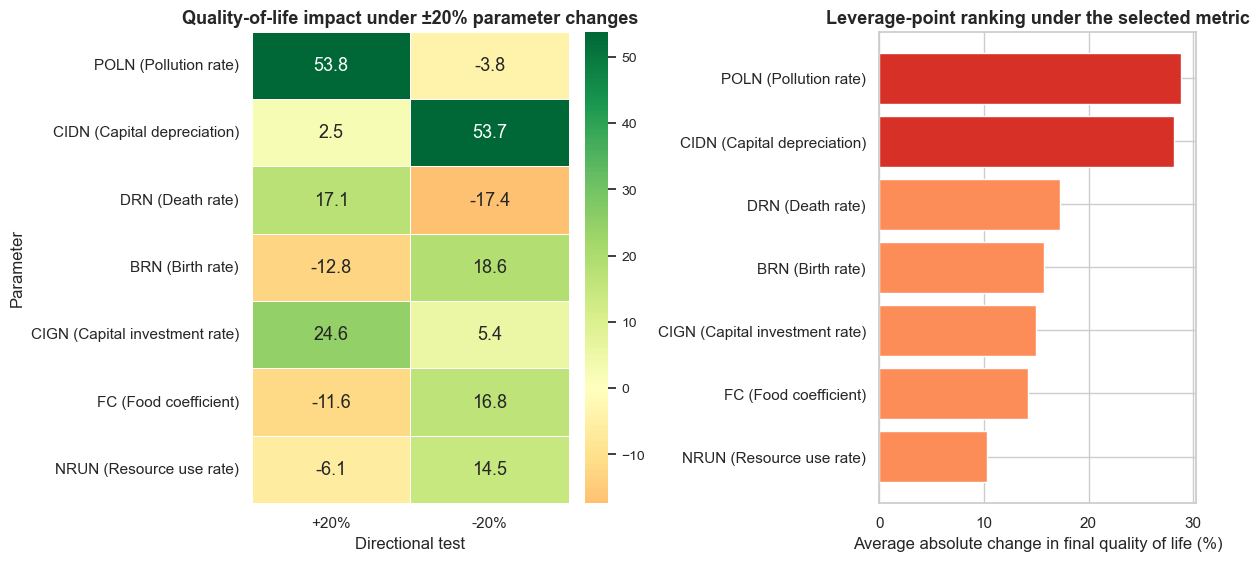

In [35]:
leverage_heatmap = leverage_results_df.pivot_table(
    index="Parameter",
    columns="Direction",
    values="Final QoL change (%)",
)

leverage_heatmap = leverage_heatmap.reindex(leverage_sensitivity_df["Parameter"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)

sns.heatmap(
    leverage_heatmap,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 13},
    ax=axes[0],
)
axes[0].set_title("Quality-of-life impact under ±20% parameter changes",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Directional test", fontsize=12)
axes[0].set_ylabel("Parameter", fontsize=12)
axes[0].tick_params(axis="x", labelsize=11)
axes[0].tick_params(axis="y", labelsize=11)
cbar0 = axes[0].collections[0].colorbar
cbar0.ax.tick_params(labelsize=10)

bar_colors = [
    "#d73027" if value > 20 else "#fc8d59" if value > 10 else "#91bfdb"
    for value in leverage_sensitivity_df["avg_qol_sensitivity"]
]

axes[1].barh(
    leverage_sensitivity_df["Parameter"],
    leverage_sensitivity_df["avg_qol_sensitivity"],
    color=bar_colors,
)
axes[1].invert_yaxis()
axes[1].set_xlabel("Average absolute change in final quality of life (%)", fontsize=12)
axes[1].set_title("Leverage-point ranking under the selected metric",
                  fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", labelsize=11)
axes[1].tick_params(axis="y", labelsize=11)

plt.show()


### Notes on interpretation

- The responses are not symmetric around the baseline, which is consistent with nonlinear feedback in the model.
- Under the selected outputs, pollution rate, capital depreciation, and demographic parameters show larger terminal quality-of-life sensitivity than the lower-ranked parameters.
- This is a leverage-point screen for the notebook's parameter exploration, not a universal policy ranking. The result depends on the chosen metrics, especially final quality of life and peak population.


## Policy synergy exploration

The leverage screen above changes one parameter at a time. To extend the parameter exploration without changing the notebook's overall structure, the next step checks whether selected policy combinations behave differently from what the single-parameter runs suggest in isolation.

The scenarios below use the same World2 model setup and compare single interventions with combined interventions under the same post-1970 switch structure.


In [14]:
synergy_scenarios = {
    "Standard (baseline)": {},
    "Lower birth rate only": {"BRN1": 0.03},
    "Reduced pollution only": {"POLN1": 0.6},
    "Reduced resource use only": {"NRUN1": 0.5},
    "Birth + Pollution": {"BRN1": 0.03, "POLN1": 0.6},
    "Birth + Resource": {"BRN1": 0.03, "NRUN1": 0.5},
    "Pollution + Resource": {"POLN1": 0.6, "NRUN1": 0.5},
    "Full sustainability (all three)": {"BRN1": 0.03, "POLN1": 0.6, "NRUN1": 0.5},
}

synergy_rows = []

for scenario_name, updates in synergy_scenarios.items():
    model = run_generated_world2(
        name="synergy_" + scenario_name.lower().replace(" ", "_").replace("+", "plus").replace("(", "").replace(")", ""),
        updates=updates,
    )

    quality_of_life = pd.Series(model.ql).dropna()
    synergy_rows.append(
        {
            "Scenario": scenario_name,
            "Peak population (billions)": model.p.max() / 1e9,
            "Peak population year": float(model.time[model.p.argmax()]),
            "Resources remaining in 2100 (%)": model.nr[-1] / model.nr[0] * 100,
            "Peak pollution (multiple of initial)": model.pol.max() / model.pol[0],
            "Peak pollution year": float(model.time[model.pol.argmax()]),
            "Final quality of life": quality_of_life.iloc[-1],
            "Minimum quality of life": quality_of_life.min(),
        }
    )

synergy_summary_df = pd.DataFrame(synergy_rows).round(
    {
        "Peak population (billions)": 3,
        "Peak population year": 1,
        "Resources remaining in 2100 (%)": 1,
        "Peak pollution (multiple of initial)": 2,
        "Peak pollution year": 1,
        "Final quality of life": 3,
        "Minimum quality of life": 3,
    }
)

display(synergy_summary_df)

synergy_base_qol = synergy_summary_df.loc[synergy_summary_df["Scenario"] == "Standard (baseline)", "Final quality of life"].iloc[0]
synergy_birth_qol = synergy_summary_df.loc[synergy_summary_df["Scenario"] == "Lower birth rate only", "Final quality of life"].iloc[0]
synergy_pollution_qol = synergy_summary_df.loc[synergy_summary_df["Scenario"] == "Reduced pollution only", "Final quality of life"].iloc[0]
synergy_combined_qol = synergy_summary_df.loc[synergy_summary_df["Scenario"] == "Birth + Pollution", "Final quality of life"].iloc[0]

sum_of_individual_effects = (synergy_birth_qol - synergy_base_qol) + (synergy_pollution_qol - synergy_base_qol)
combined_effect = synergy_combined_qol - synergy_base_qol
interaction_gap = combined_effect - sum_of_individual_effects

synergy_interaction_df = pd.DataFrame(
    [
        {
            "Baseline final QoL": synergy_base_qol,
            "Birth-only QoL gain": synergy_birth_qol - synergy_base_qol,
            "Pollution-only QoL gain": synergy_pollution_qol - synergy_base_qol,
            "Sum of individual effects": sum_of_individual_effects,
            "Combined effect (Birth + Pollution)": combined_effect,
            "Interaction gap": interaction_gap,
        }
    ]
).round(3)

display(synergy_interaction_df)


,Scenario,Peak population (billions),Peak population year,Resources remaining in 2100 (%),Peak pollution (multiple of initial),Peak pollution year,Final quality of life,Minimum quality of life
0,Standard (baseline),5.296,2020.4,30.9,102.83,2050.6,0.549,0.549
1,Lower birth rate only,4.660,2026.4,30.4,118.81,2051.0,0.678,0.616
2,Reduced pollution only,5.508,2024.8,31.0,34.45,2046.2,0.515,0.515
3,Reduced resource use only,5.666,2030.4,50.4,733.31,2065.8,3.863,0.245
4,Birth + Pollution,4.993,2032.0,30.3,37.77,2046.2,0.635,0.616
5,Birth + Resource,4.952,2030.4,50.8,727.03,2059.0,4.108,0.277
6,Pollution + Resource,6.342,2055.6,43.9,74.82,2082.4,0.594,0.594
7,Full sustainability (all three),5.695,2056.4,43.0,94.57,2083.0,0.736,0.616


,Baseline final QoL,Birth-only QoL gain,Pollution-only QoL gain,Sum of individual effects,Combined effect (Birth + Pollution),Interaction gap
0,0.549,0.129,-0.034,0.095,0.086,-0.009


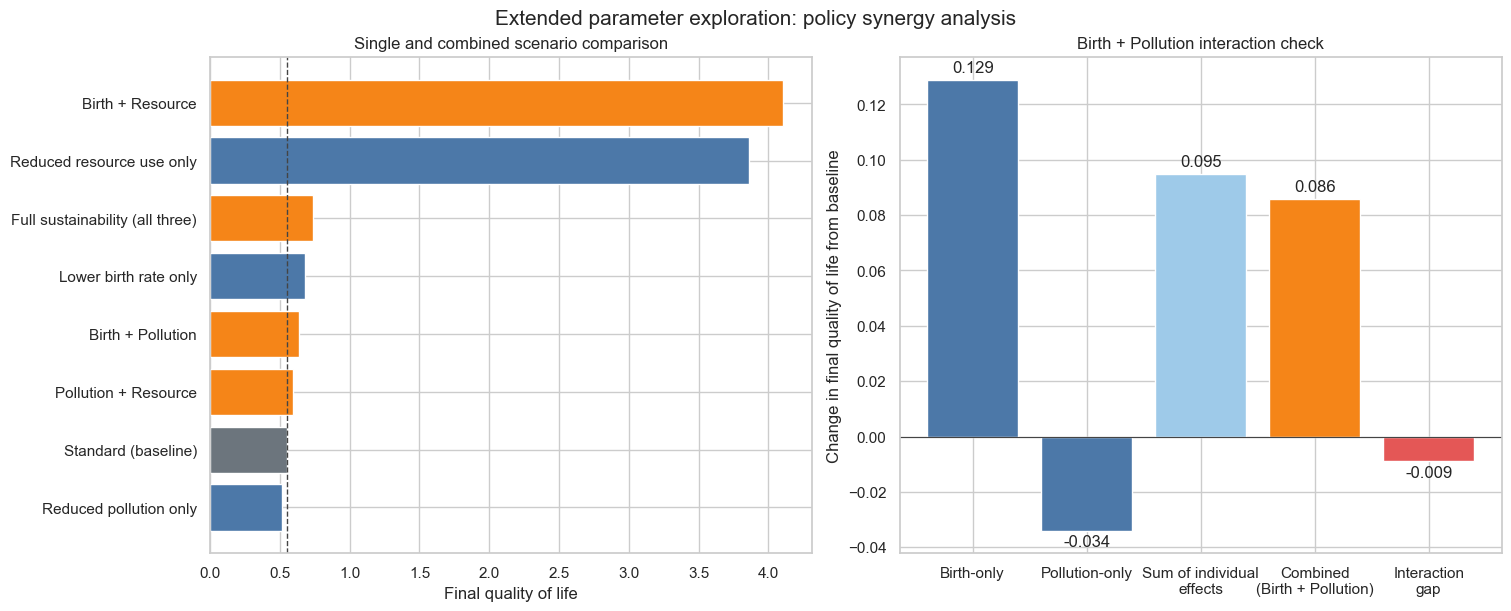

In [15]:
synergy_plot_df = synergy_summary_df.sort_values("Final quality of life")
synergy_colors = [
    "#6c757d" if "Standard" in scenario else "#4c78a8" if "only" in scenario else "#f58518"
    for scenario in synergy_plot_df["Scenario"]
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

axes[0].barh(
    synergy_plot_df["Scenario"],
    synergy_plot_df["Final quality of life"],
    color=synergy_colors,
)
axes[0].axvline(synergy_base_qol, linestyle="--", color="#444444", linewidth=1)
axes[0].set_xlabel("Final quality of life")
axes[0].set_title("Single and combined scenario comparison")

interaction_labels = [
    "Birth-only",
    "Pollution-only",
    "Sum of individual\neffects",
    "Combined\n(Birth + Pollution)",
    "Interaction\ngap",
]
interaction_values = [
    synergy_birth_qol - synergy_base_qol,
    synergy_pollution_qol - synergy_base_qol,
    sum_of_individual_effects,
    combined_effect,
    interaction_gap,
]
interaction_colors = [
    "#4c78a8",
    "#4c78a8",
    "#9ecae9",
    "#f58518",
    "#54a24b" if interaction_gap > 0 else "#e45756",
]

bars = axes[1].bar(interaction_labels, interaction_values, color=interaction_colors)
axes[1].axhline(0, color="#444444", linewidth=0.8)
axes[1].set_ylabel("Change in final quality of life from baseline")
axes[1].set_title("Birth + Pollution interaction check")

for bar, value in zip(bars, interaction_values):
    vertical_alignment = "bottom" if value >= 0 else "top"
    y_offset = 3 if value >= 0 else -3
    axes[1].annotate(
        f"{value:.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, y_offset),
        textcoords="offset points",
        ha="center",
        va=vertical_alignment,
    )

fig.suptitle("Extended parameter exploration: policy synergy analysis", fontsize=15)
plt.show()


### Notes on interaction results

- The combined scenarios give a direct way to check whether policy interaction differs from what the single-parameter runs imply on their own.
- Under the selected metric in this notebook, the `Birth + Pollution` case improves final quality of life relative to the baseline, but the interaction gap should still be read directly rather than assumed to be positive.
- As with the leverage-point screen, this interaction result is conditional on the chosen output metric and is best interpreted as part of the notebook's parameter exploration rather than as a general policy conclusion.
